# 🫀 ECG Arrhythmia Classification — Part A: Environment Setup

**Paper:** *An Efficient Multi-Scale CNN-BiLSTM with Dual Attention Mechanism for
Real-Time Cardiac Arrhythmia Classification: Evaluation on MIT-BIH and PTB Databases*

**Research question:** Can a lightweight Multi-Scale CNN-BiLSTM with Dual Attention achieve
high accuracy AND real-time efficiency for 5-class cardiac arrhythmia classification, validated
under the strict inter-patient paradigm and on external databases (PTB-XL screening, INCART
full validation)?

---

## Novel Contributions
| # | Contribution | Details |
|---|---|---|
| 1 | **Multi-scale CNN-BiLSTM with dual attention** | Parallel Conv1D branches (k=3, 7, 15) + channel attention (SE-style) + temporal attention, feeding a 2-layer BiLSTM — captures fine QRS detail, P/T-wave shape, and overall morphology simultaneously, then learns *which channels* and *which time steps* matter most |
| 2 | **Strict inter-patient evaluation** | AAMI v4 patient-aware split — zero patient overlap between train/test |
| 3 | **EMD feature engineering (parallel track)** | 67 features: 43 IMF statistics + 12 waveform morphology + 8 P-wave + 4 RR intervals, used for the classical-ML / MRMR comparison track (Parts C–D) |
| 4 | **S-class targeted SMOTE** | Dedicated oversampling for the hardest minority class (S-class) |
| 5 | **MRMR feature selection** | Top-40 most discriminative features from 67-dim EMD space |
| 6 | **Real-time efficiency reporting** | Model size (MB) and per-beat inference time (ms) reported alongside accuracy — the gap explicitly left open by CBGM (Bai et al., 2024), CAT-Net (Islam et al., 2024), and Gupta et al.'s 2024 survey |
| 7 | **External validation** | PTB-XL directional screening + full INCART validation with matching AAMI beat-symbol convention |

---

## Pipeline Overview

```
Raw ECG (MIT-BIH, 360 Hz)
        │
        ▼
┌────────────────────────────────────────────┐
│  Part B — Preprocessing                    │
│  • Bandpass filter (0.5 – 45 Hz)           │
│  • Sym4 wavelet denoising                  │
│  • R-peak detection & validation           │
│  • Beat segmentation  →  (N × 360)         │
│  • RR interval computation                 │
└───────────────┬────────────────────────────┘
                │
                ▼
┌────────────────────────────────────────────┐
│  Part C — EMD Feature Extraction           │
│  • 67-dim feature vector per beat          │
│  (parallel classical-ML comparison track)  │
└───────────────┬────────────────────────────┘
                │
                ▼
┌────────────────────────────────────────────┐
│  Part D — Split · MRMR · S-SMOTE          │
│  • DS1 / DS2 inter-patient split           │
│  • StandardScaler                          │
│  • MRMR top-40 feature selection           │
│  • S-class targeted SMOTE                  │
└───────────────┬────────────────────────────┘
                │
                ▼
┌────────────────────────────────────────────┐
│  Part E — Deep Learning Classifiers        │
│  • Full-class balanced SMOTE               │
│  • CNN  (single-scale baseline)            │
│  • BiLSTM  (baseline)                      │
│  • Multi-Scale CNN-BiLSTM + Dual Attention │
│    ← proposed model                        │
│  • Per-class Se / Sp / PPV / F1 + AUC-ROC │
│  • Model size (MB) + inference time (ms)   │
└───────────────┬────────────────────────────┘
                │
                ▼
┌────────────────────────────────────────────┐
│  Part F — Ensemble + Optuna + SHAP         │
│  • Soft-voting & stacking across models    │
│  • Optuna tuning of the proposed model     │
│  • SHAP explainability                     │
│  • Literature comparison                   │
└───────────────┬────────────────────────────┘
                │
                ▼
┌────────────────────────────────────────────┐
│  Part G — External Validation              │
│  • INCART (matching AAMI beat symbols)     │
│  • Apples-to-apples vs MIT-BIH DS2 metrics │
└────────────────────────────────────────────┘
```

---

## Results Tracking
| Model | Accuracy | Macro-F1 | S-class F1 | Model Size (MB) | Inference (ms/beat) |
|---|---|---|---|---|---|
| CNN (baseline) | TBD | TBD | TBD | TBD | TBD |
| BiLSTM (baseline) | TBD | TBD | TBD | TBD | TBD |
| **Multi-Scale CNN-BiLSTM + Dual Attention (proposed)** | **TBD** | **TBD** | **TBD** | **TBD** | **TBD** |

---
**This notebook (Part A):** Environment setup, dataset download, AAMI class mapping, and full sanity checks.


## A1 — Project Paths & Directory Setup

In [ ]:
# A1 — Project paths and directory setup
# ──────────────────────────────────────────────────────────────────────────
# All intermediate outputs (preprocessed beats, features, model weights,
# predictions, figures) are saved to disk after every expensive step.
# This protects against disconnects during long operations
# (SMOTE ~15 min, CNN-BiLSTM training ~30–90 min depending on hardware).
#
# ⚙  Adjust PROJECT_DIR to your local ch eckout or Colab Drive mount point.

import os
from pathlib import Path

if os.path.exists("/content"):          # Google Colab
    PROJECT_DIR = Path("/content/drive/MyDrive/ecg_project")
else:                                     # local machine
    PROJECT_DIR = Path("./ecg_project")

SAVE_DIR   = str(PROJECT_DIR / "results")
FIGS_DIR   = str(PROJECT_DIR / "figures")
DATA_ROOT  = str(PROJECT_DIR / "mitdb")
MODELS_DIR = str(PROJECT_DIR / "models")
CKPT_DIR   = str(PROJECT_DIR / "checkpoints")

for path in [SAVE_DIR, FIGS_DIR, DATA_ROOT, MODELS_DIR, CKPT_DIR]:
    os.makedirs(path, exist_ok=True)

# Verify SAVE_DIR is writable before any computation starts
_test = os.path.join(SAVE_DIR, ".write_test")
with open(_test, "w", encoding="utf-8") as f:
    f.write("ok")
os.remove(_test)

print("✓ Project directories ready")
print(f"  PROJECT_DIR : {PROJECT_DIR}")
print(f"  SAVE_DIR    : {SAVE_DIR}")
print(f"  MODELS_DIR  : {MODELS_DIR}")
print(f"  CKPT_DIR    : {CKPT_DIR}")
print(f"  DATA_ROOT   : {DATA_ROOT}")


✓ Project directories ready
  PROJECT_DIR : D:\Downloads\ecg_project_complete\ecg_project
  SAVE_DIR    : D:\Downloads\ecg_project_complete\ecg_project\results
  MODELS_DIR  : D:\Downloads\ecg_project_complete\ecg_project\models
  CKPT_DIR    : D:\Downloads\ecg_project_complete\ecg_project\checkpoints
  DATA_ROOT   : D:\Downloads\ecg_project_complete\ecg_project\mitdb


## A2 — Install Dependencies

In [2]:
# A2 — Install all required packages
# ──────────────────────────────────────────────────────────────────────────
# Package              Version       Purpose                      Used in
# ──────────────────────────────────────────────────────────────────────────
# wfdb                 ≥4.1.0        Read MIT-BIH PhysioNet files Parts A–F
# EMD-signal           ≥1.9.0        Empirical Mode Decomposition  Part C
# antropy              ≥0.1.6        Sample / permutation entropy  Part C
# scikit-learn         ≥1.3.0        Preprocessing, metrics        Parts D–F
# imbalanced-learn     ≥0.12.0       SMOTE resampling              Parts D, E
# mrmr-selection       ≥0.2.8        MRMR feature selection        Part D
# tensorflow           ≥2.13         CNN / BiLSTM / CNN-BiLSTM     Part E
# optuna               ≥3.4          Hyperparameter tuning         Part F
# shap                 ≥0.44         Model explainability          Part F

import sys
import subprocess

def pip_install(package, import_name=None):
    name = import_name or package.split("[")[0].split(">")[0].split("<")[0].split("==")[0]
    try:
        __import__(name)
        print(f"  ✓ {package:<35} already installed")
    except ImportError:
        print(f"  ⬇  {package:<35} installing ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"  ✓ {package:<35} done")

packages = [
    ("numpy<2",                "numpy"),
    ("scipy<2",                "scipy"),
    ("pandas",                 "pandas"),
    ("matplotlib",             "matplotlib"),
    ("wfdb",                   "wfdb"),
    ("EMD-signal",             "PyEMD"),
    ("antropy",                "antropy"),
    ("scikit-learn>=1.3.0",    "sklearn"),
    ("imbalanced-learn>=0.12.0","imblearn"),
    ("mrmr-selection",         "mrmr"),
    ("joblib",                 "joblib"),
    ("tensorflow>=2.13",       "tensorflow"),
    ("optuna",                 "optuna"),
    ("shap",                   "shap"),
]

print("Installing packages:")
for pkg, imp in packages:
    pip_install(pkg, imp)

print("\n✓ All dependencies satisfied")


Installing packages:
  ✓ numpy<2                             already installed
  ✓ scipy<2                             already installed
  ✓ pandas                              already installed
  ✓ matplotlib                          already installed
  ✓ wfdb                                already installed
  ✓ EMD-signal                          already installed
  ✓ antropy                             already installed
  ✓ scikit-learn>=1.3.0                 already installed
  ✓ imbalanced-learn>=0.12.0            already installed
  ✓ mrmr-selection                      already installed
  ✓ joblib                              already installed
  ✓ tensorflow>=2.13                    already installed
  ✓ optuna                              already installed
  ✓ shap                                already installed

✓ All dependencies satisfied


## A3 — Core Imports & Global Constants

In [3]:
# A3 — Core imports and global constants shared across all Part notebooks
# ──────────────────────────────────────────────────────────────────────────

import os
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import wfdb
import tensorflow as tf

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ── AAMI five-class scheme (AAMI EC57:1998) ────────────────────────────────
AAMI_LABELS = {0: "N", 1: "S", 2: "V", 3: "F", 4: "Q"}
AAMI_COLORS = {
    "N": "#4878CF",   # blue
    "S": "#D65F5F",   # red   ← primary SMOTE target (rarest, clinically critical)
    "V": "#6ACC65",   # green
    "F": "#B47CC7",   # purple
    "Q": "#C4AD66",   # gold
}

# MIT-BIH annotation symbol → AAMI integer class
BEAT_MAP = {
    # N — Normal + bundle-branch variants
    "N": 0, "L": 0, "R": 0, "B": 0, "e": 0, "j": 0, "n": 0,
    # S — Supraventricular ectopic  (most imbalanced → S-SMOTE target)
    "A": 1, "a": 1, "J": 1, "S": 1,
    # V — Ventricular ectopic
    "V": 2, "E": 2,
    # F — Fusion
    "F": 3,
    # Q — Unclassifiable / paced
    "/": 4, "f": 4, "Q": 4, "?": 4,
}

# ── MIT-BIH inter-patient split (AAMI v4) ─────────────────────────────────
# DS1 → train  |  DS2 → test   (zero patient overlap — strict paradigm)
DS1_RECORDS = [101,106,108,109,112,114,115,116,118,119,
               122,124,201,203,205,207,208,209,215,220,
               223,230]
DS2_RECORDS = [100,103,105,111,113,117,121,123,200,202,
               210,212,213,214,219,221,222,228,231,232,
               233,234]

# ── Orphan records (excluded from de Chazal DS1/DS2 — contain paced beats) ─
# These 4 patients are NOT in either AAMI list but carry >99% of all Q-class
# (paced/unknown) beats in MIT-BIH. They MUST still be loaded and processed
# (see Part B), then handled via the force-split logic in Part D — they are
# simply excluded from the *standard* inter-patient train/test assignment.
ORPHAN_RECORDS = [102, 104, 107, 217]

# ── Signal / preprocessing constants ──────────────────────────────────────
FS        = 360      # sampling rate (Hz)
BEAT_LEN  = 360      # samples per beat window (1 s @ 360 Hz)
PRE_SAMP  = 100      # samples before R-peak
POST_SAMP = 260      # samples after  R-peak
BP_LOW    = 0.5      # bandpass lower cut-off (Hz)
BP_HIGH   = 45.0     # bandpass upper cut-off (Hz)
WAVELET   = "sym4"   # Symlet-4 wavelet for denoising

# ── EMD / feature constants ────────────────────────────────────────────────
N_IMFS     = 8       # IMFs extracted per beat
N_FEATURES = 67      # total EMD feature dimension
N_MRMR     = 40      # MRMR top-k kept for downstream use

# ── Deep learning constants (CNN / BiLSTM / CNN-BiLSTM) ───────────────────
N_CLASSES   = 5      # AAMI classes
DL_EPOCHS   = 30     # maximum training epochs (early stopping applies)
DL_BATCH    = 128    # mini-batch size
DL_LR       = 1e-3   # initial Adam learning rate
DL_PATIENCE = 10     # early-stopping patience (epochs without val-F1 gain)
DL_DROPOUT  = 0.3    # dropout rate used in all three architectures

print("✓ Global constants defined")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  AAMI classes: {AAMI_LABELS}")
print(f"  DS1 (train) : {len(DS1_RECORDS)} patients")
print(f"  DS2 (test)  : {len(DS2_RECORDS)} patients")
print(f"  Orphan      : {len(ORPHAN_RECORDS)} patients  {ORPHAN_RECORDS}  (force-split in Part D)")
print(f"  Beat window : {BEAT_LEN} samples  ({BEAT_LEN/FS*1000:.0f} ms @ {FS} Hz)")
print(f"  EMD features: {N_FEATURES} dims  →  MRMR top-{N_MRMR}")
print(f"  DL settings : epochs={DL_EPOCHS}  batch={DL_BATCH}  lr={DL_LR}  patience={DL_PATIENCE}  dropout={DL_DROPOUT}")


✓ Global constants defined
  TensorFlow  : 2.21.0
  AAMI classes: {0: 'N', 1: 'S', 2: 'V', 3: 'F', 4: 'Q'}
  DS1 (train) : 22 patients
  DS2 (test)  : 22 patients
  Orphan      : 4 patients  [102, 104, 107, 217]  (force-split in Part D)
  Beat window : 360 samples  (1000 ms @ 360 Hz)
  EMD features: 67 dims  →  MRMR top-40
  DL settings : epochs=30  batch=128  lr=0.001  patience=10  dropout=0.3


## A4 — Download MIT-BIH Arrhythmia Database

In [4]:
# A4 — Download MIT-BIH from PhysioNet (idempotent — skips if present)
# ──────────────────────────────────────────────────────────────────────────
# 48 half-hour two-lead ECG recordings at 360 Hz, annotated beat-by-beat
# by two independent cardiologists.  Total size: ~100 MB.

import wfdb

ALL_RECORDS = sorted(set(DS1_RECORDS + DS2_RECORDS + ORPHAN_RECORDS))  # 48 total

def mitdb_ready(root, records, min_files=5):
    return sum(os.path.exists(os.path.join(root, f"{r}.hea")) for r in records) >= min_files

if mitdb_ready(DATA_ROOT, ALL_RECORDS):
    found = sum(os.path.exists(os.path.join(DATA_ROOT, f"{r}.hea")) for r in ALL_RECORDS)
    print(f"✓ MIT-BIH already present — {found}/{len(ALL_RECORDS)} records found")
    print(f"  Path: {DATA_ROOT}")
else:
    print("⬇  Downloading MIT-BIH Arrhythmia Database (~100 MB) ...")
    wfdb.dl_database("mitdb", dl_dir=DATA_ROOT)
    print(f"✓ Download complete → {DATA_ROOT}")

missing = [r for r in ALL_RECORDS if not os.path.exists(os.path.join(DATA_ROOT, f"{r}.hea"))]
if missing:
    print(f"\n⚠  Missing records: {missing}")
    print("   Re-run this cell or download manually:")
    print("   https://physionet.org/content/mitdb/")
else:
    print(f"✓ All {len(ALL_RECORDS)} records verified")


✓ MIT-BIH already present — 48/48 records found
  Path: D:\Downloads\ecg_project_complete\ecg_project\mitdb
✓ All 48 records verified


## A5 — AAMI Mapping Sanity Check

In [5]:
# A5 — Verify AAMI beat-type mapping across all records
# ──────────────────────────────────────────────────────────────────────────
# Reads every annotation file, counts mapped beats per AAMI class,
# and reports unknown symbols so BEAT_MAP can be extended if needed.

from collections import Counter

ALL_RECORDS = sorted(set(DS1_RECORDS + DS2_RECORDS + ORPHAN_RECORDS))  # 48 total
total_beats  = 0
class_counts = Counter()
unknown_syms = Counter()

for rec_id in ALL_RECORDS:
    rec_path = os.path.join(DATA_ROOT, str(rec_id))
    try:
        ann = wfdb.rdann(rec_path, "atr")
    except FileNotFoundError:
        print(f"  ⚠  {rec_id}: annotation file missing — skipping")
        continue
    for sym in ann.symbol:
        if sym in BEAT_MAP:
            class_counts[AAMI_LABELS[BEAT_MAP[sym]]] += 1
            total_beats += 1
        else:
            unknown_syms[sym] += 1

print("AAMI Class Distribution — Full MIT-BIH Dataset")
print("-" * 50)
for cls in ["N", "S", "V", "F", "Q"]:
    n   = class_counts[cls]
    pct = 100 * n / total_beats if total_beats else 0
    bar = "█" * int(pct / 2)
    print(f"  {cls}  {n:>8,d}  ({pct:5.1f}%)  {bar}")
print("-" * 50)
print(f"  Total mapped beats : {total_beats:,}")

if unknown_syms:
    print(f"\n  ⚠  Unmapped symbols (excluded):")
    for sym, cnt in unknown_syms.most_common():
        print(f"     '{sym}'  →  {cnt:,} occurrences")
else:
    print("\n✓ All annotation symbols mapped — BEAT_MAP is complete")

print("\n  Imbalance ratios  (N : class)")
for cls in ["S", "V", "F", "Q"]:
    ratio = class_counts["N"] / class_counts[cls] if class_counts[cls] else float("inf")
    print(f"    N : {cls}  =  {ratio:>8,.0f} : 1")
print("\n  ⚑  S-class has the highest N:S ratio → primary SMOTE target")


AAMI Class Distribution — Full MIT-BIH Dataset
--------------------------------------------------
  N    90,631  ( 82.8%)  █████████████████████████████████████████
  S     2,781  (  2.5%)  █
  V     7,236  (  6.6%)  ███
  F       803  (  0.7%)  
  Q     8,043  (  7.3%)  ███
--------------------------------------------------
  Total mapped beats : 109,494

  ⚠  Unmapped symbols (excluded):
     '+'  →  1,291 occurrences
     '~'  →  616 occurrences
     '!'  →  472 occurrences
     '"'  →  437 occurrences
     'x'  →  193 occurrences
     '|'  →  132 occurrences
     '['  →  6 occurrences
     ']'  →  6 occurrences

  Imbalance ratios  (N : class)
    N : S  =        33 : 1
    N : V  =        13 : 1
    N : F  =       113 : 1
    N : Q  =        11 : 1

  ⚑  S-class has the highest N:S ratio → primary SMOTE target


## A6 — Inter-Patient Split Verification

In [6]:
# A6 — Confirm zero patient overlap between DS1 (train) and DS2 (test)
# ──────────────────────────────────────────────────────────────────────────
# The inter-patient paradigm prevents any single patient's ECG morphology
# from leaking into both train and test, giving a true generalisation measure.

ds1_set = set(DS1_RECORDS)
ds2_set = set(DS2_RECORDS)
overlap  = ds1_set & ds2_set

print("Inter-Patient Split Summary")
print("-" * 42)
print(f"  DS1 (train) : {len(ds1_set):>3d} patients → {sorted(ds1_set)}")
print(f"  DS2 (test)  : {len(ds2_set):>3d} patients → {sorted(ds2_set)}")
print()

if overlap:
    print(f"  ⛔  OVERLAP DETECTED: {overlap}")
    print("      Fix DS1_RECORDS / DS2_RECORDS in A3 before continuing!")
else:
    print("  ✓  Zero patient overlap confirmed (strict inter-patient paradigm)")

print()
print("  Estimated beat counts per split:")
for label, records in [("DS1 (train)", DS1_RECORDS), ("DS2 (test)", DS2_RECORDS)]:
    n = 0
    for rec_id in records:
        rec_path = os.path.join(DATA_ROOT, str(rec_id))
        try:
            ann = wfdb.rdann(rec_path, "atr")
            n  += sum(1 for s in ann.symbol if s in BEAT_MAP)
        except FileNotFoundError:
            pass
    print(f"    {label:<14}: ~{n:,} beats")


Inter-Patient Split Summary
------------------------------------------
  DS1 (train) :  22 patients → [101, 106, 108, 109, 112, 114, 115, 116, 118, 119, 122, 124, 201, 203, 205, 207, 208, 209, 215, 220, 223, 230]
  DS2 (test)  :  22 patients → [100, 103, 105, 111, 113, 117, 121, 123, 200, 202, 210, 212, 213, 214, 219, 221, 222, 228, 231, 232, 233, 234]

  ✓  Zero patient overlap confirmed (strict inter-patient paradigm)

  Estimated beat counts per split:
    DS1 (train)   : ~51,021 beats
    DS2 (test)    : ~49,712 beats


## A7 — Sample ECG Visualisation (one beat per AAMI class)

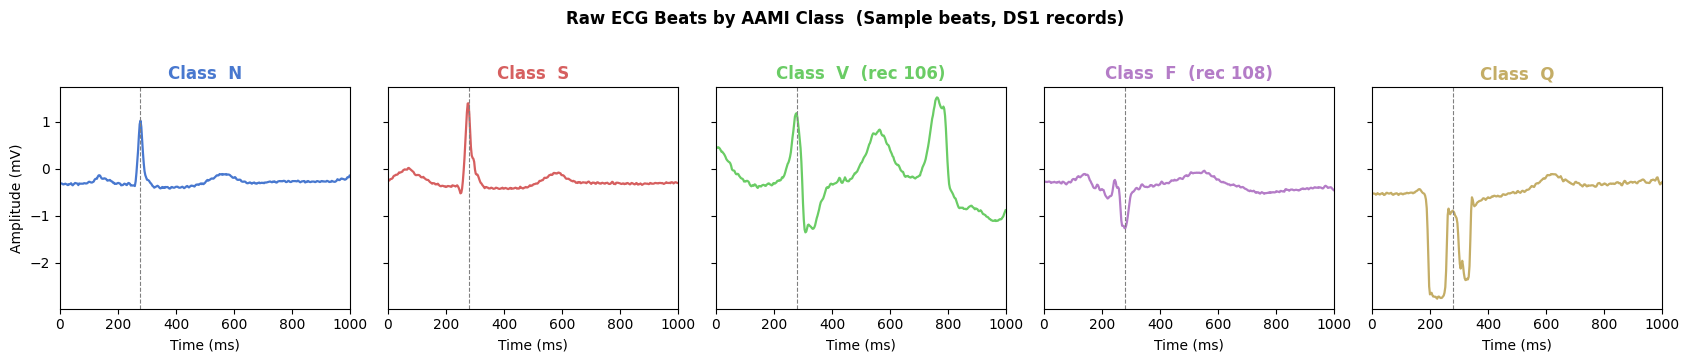

✓ Saved D:\Downloads\ecg_project_complete\ecg_project\figures\A7_sample_beats.png


In [7]:
# A7 — Plot one raw beat per AAMI class (search across DS1 records so every
#       class — including rare V and F beats — gets a real example)
# ──────────────────────────────────────────────────────────────────────────
# Full preprocessing (bandpass + wavelet denoising) is applied in Part B.
# This cell shows the raw segmented waveforms so you can verify the
# beat-centred window (PRE_SAMP samples before R-peak, POST_SAMP after).

SAMPLE_REC = 101  # primary record, used first / shown in the title

examples = {}

# Try the primary record first, then fall back to other DS1 records for
# any class that record 101 doesn't contain (V and F are rare).
search_order = [SAMPLE_REC] + [r for r in DS1_RECORDS if r != SAMPLE_REC]

for rec_id in search_order:
    if len(examples) == N_CLASSES:
        break
    rec_path = os.path.join(DATA_ROOT, str(rec_id))
    try:
        record = wfdb.rdrecord(rec_path)
        ann    = wfdb.rdann(rec_path, "atr")
    except FileNotFoundError:
        continue
    signal = record.p_signal[:, 0]   # Lead II

    for idx, sym in enumerate(ann.symbol):
        if sym not in BEAT_MAP:
            continue
        cls = BEAT_MAP[sym]
        if cls in examples:
            continue
        peak = ann.sample[idx]
        if peak - PRE_SAMP < 0 or peak + POST_SAMP > len(signal):
            continue
        examples[cls] = (rec_id, signal[peak - PRE_SAMP : peak + POST_SAMP])
        if len(examples) == N_CLASSES:
            break

t = np.arange(PRE_SAMP + POST_SAMP) / FS * 1000   # ms axis

fig, axes = plt.subplots(1, N_CLASSES, figsize=(17, 3.5), sharey=True)

for ax, cls_int in zip(axes, range(N_CLASSES)):     # always all 5 classes
    cls_name = AAMI_LABELS[cls_int]
    color    = AAMI_COLORS[cls_name]

    if cls_int in examples:
        src_rec, beat = examples[cls_int]
        ax.plot(t, beat, color=color, lw=1.6)
        ax.axvline(PRE_SAMP / FS * 1000, color="grey", lw=0.8, ls="--", label="R-peak")
        title = f"Class  {cls_name}"
        if src_rec != SAMPLE_REC:
            title += f"  (rec {src_rec})"   # flag when borrowed from another record
    else:
        ax.text(0.5, 0.5, "No beat found\nin DS1", ha="center", va="center",
                 transform=ax.transAxes, fontsize=9, color="grey")
        title = f"Class  {cls_name}"

    ax.set_title(title, fontweight="bold", color=color, fontsize=12)
    ax.set_xlabel("Time (ms)")
    ax.set_xlim(0, (PRE_SAMP + POST_SAMP) / FS * 1000)
    if ax is axes[0]:
        ax.set_ylabel("Amplitude (mV)")

plt.suptitle(f"Raw ECG Beats by AAMI Class  (Sample beats, DS1 records)",
             fontweight="bold", y=1.02)
plt.tight_layout()

out = os.path.join(FIGS_DIR, "A7_sample_beats.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved {out}")

## A8 — GPU / Hardware Check

In [8]:
# A8 — Detect GPU and configure TensorFlow for CNN / BiLSTM / CNN-BiLSTM
# ──────────────────────────────────────────────────────────────────────────
# All three deep learning models in Part E benefit significantly from GPU.
# This cell reports available hardware and estimated training times.

import platform
import tensorflow as tf

print(f"  System     : {platform.platform()}")
print(f"  Python     : {platform.python_version()}")
print(f"  TensorFlow : {tf.__version__}")
print()

gpus = tf.config.list_physical_devices("GPU")
cpus = tf.config.list_physical_devices("CPU")

if gpus:
    print(f"✓ GPU detected — {len(gpus)} device(s):")
    for g in gpus:
        print(f"    {g.name}")
        try:
            details = tf.config.experimental.get_device_details(g)
            print(f"      → {details.get('device_name', 'unknown')}")
        except Exception:
            pass
        try:
            tf.config.experimental.set_memory_growth(g, True)
            print(f"      → memory growth enabled")
        except RuntimeError:
            pass
    print()
    print("  Estimated Part E training times (per model, GPU):")
    print("    CNN         : ~10 – 20 min")
    print("    BiLSTM      : ~20 – 35 min")
    print("    CNN-BiLSTM  : ~25 – 45 min")
else:
    print(f"⚠  No GPU detected — using CPU ({len(cpus)} logical device(s))")
    print()
    print("  Estimated Part E training times (per model, CPU):")
    print("    CNN         : ~30 –  60 min")
    print("    BiLSTM      : ~60 – 120 min")
    print("    CNN-BiLSTM  : ~90 – 180 min")
    print()
    print("  ⚑  To enable GPU on Colab:")
    print("     Runtime → Change runtime type → Hardware accelerator → GPU")


  System     : Windows-10-10.0.26200-SP0
  Python     : 3.11.5
  TensorFlow : 2.21.0

⚠  No GPU detected — using CPU (1 logical device(s))

  Estimated Part E training times (per model, CPU):
    CNN         : ~30 –  60 min
    BiLSTM      : ~60 – 120 min
    CNN-BiLSTM  : ~90 – 180 min

  ⚑  To enable GPU on Colab:
     Runtime → Change runtime type → Hardware accelerator → GPU


## A9 — Save Shared Constants to Disk

In [9]:
# A9 — Persist all constants to JSON so Parts B–F never need to re-run Part A
# ──────────────────────────────────────────────────────────────────────────

import json

constants = {
    "SEED"        : SEED,
    "FS"          : FS,
    "BEAT_LEN"    : BEAT_LEN,
    "PRE_SAMP"    : PRE_SAMP,
    "POST_SAMP"   : POST_SAMP,
    "BP_LOW"      : BP_LOW,
    "BP_HIGH"     : BP_HIGH,
    "WAVELET"     : WAVELET,
    "N_IMFS"      : N_IMFS,
    "N_FEATURES"  : N_FEATURES,
    "N_MRMR"      : N_MRMR,
    "N_CLASSES"   : N_CLASSES,
    "DL_EPOCHS"   : DL_EPOCHS,
    "DL_BATCH"    : DL_BATCH,
    "DL_LR"       : DL_LR,
    "DL_PATIENCE" : DL_PATIENCE,
    "DL_DROPOUT"  : DL_DROPOUT,
    "AAMI_LABELS" : AAMI_LABELS,
    "AAMI_COLORS" : AAMI_COLORS,
    "BEAT_MAP"    : BEAT_MAP,
    "DS1_RECORDS" : DS1_RECORDS,
    "DS2_RECORDS" : DS2_RECORDS,
    "ORPHAN_RECORDS": ORPHAN_RECORDS,
    "SAVE_DIR"    : SAVE_DIR,
    "FIGS_DIR"    : FIGS_DIR,
    "DATA_ROOT"   : DATA_ROOT,
    "MODELS_DIR"  : MODELS_DIR,
    "CKPT_DIR"    : CKPT_DIR,
}

out_path = os.path.join(SAVE_DIR, "pipeline_constants.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(constants, f, indent=2)

print(f"✓ Constants saved → {out_path}")
print()
for k, v in constants.items():
    if isinstance(v, (list, dict)):
        print(f"  {k:<16}: {type(v).__name__} ({len(v)} items)")
    else:
        print(f"  {k:<16}: {v}")


✓ Constants saved → D:\Downloads\ecg_project_complete\ecg_project\results\pipeline_constants.json

  SEED            : 42
  FS              : 360
  BEAT_LEN        : 360
  PRE_SAMP        : 100
  POST_SAMP       : 260
  BP_LOW          : 0.5
  BP_HIGH         : 45.0
  WAVELET         : sym4
  N_IMFS          : 8
  N_FEATURES      : 67
  N_MRMR          : 40
  N_CLASSES       : 5
  DL_EPOCHS       : 30
  DL_BATCH        : 128
  DL_LR           : 0.001
  DL_PATIENCE     : 10
  DL_DROPOUT      : 0.3
  AAMI_LABELS     : dict (5 items)
  AAMI_COLORS     : dict (5 items)
  BEAT_MAP        : dict (18 items)
  DS1_RECORDS     : list (22 items)
  DS2_RECORDS     : list (22 items)
  ORPHAN_RECORDS  : list (4 items)
  SAVE_DIR        : D:\Downloads\ecg_project_complete\ecg_project\results
  FIGS_DIR        : D:\Downloads\ecg_project_complete\ecg_project\figures
  DATA_ROOT       : D:\Downloads\ecg_project_complete\ecg_project\mitdb
  MODELS_DIR      : D:\Downloads\ecg_project_complete\ecg_project

## A10 — Part A Summary & Next Steps

In [10]:
# A10 — Summary and roadmap for the rest of the pipeline
# ──────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("  Part A Complete — Environment Setup")
print("=" * 60)
print()
print("  ✓ Project directories created and verified writable")
print("  ✓ All dependencies installed  (core + TensorFlow)")
print("  ✓ Global constants defined and saved to disk")
print("  ✓ MIT-BIH dataset downloaded and verified")
print("  ✓ AAMI class mapping validated across all records")
print("  ✓ Inter-patient split verified (zero DS1/DS2 overlap)")
print("  ✓ Sample beats visualised per AAMI class")
print("  ✓ GPU / hardware availability reported")
print()
print("  ─── Pipeline roadmap ──────────────────────────────────")
print()
print("  Part B — Preprocessing")
print("    Bandpass filter + Sym4 wavelet denoising")
print("    R-peak detection, beat segmentation (360 samples)")
print("    RR interval computation")
print("    Outputs: X_beats.npy  y_labels.npy  rr_features.npy")
print()
print("  Part C — EMD Feature Extraction")
print("    67-dim feature vector per beat via EMD")
print("    Outputs: X_features.npy  feature_names.npy")
print()
print("  Part D — Split · MRMR · S-SMOTE")
print("    DS1/DS2 split, StandardScaler, MRMR top-40")
print("    S-class targeted SMOTE")
print("    Outputs: X_train_smote.npy  X_test_40.npy  y_train_smote.npy")
print()
print("  Part E — Deep Learning Classifiers")
print("    Full-class balanced SMOTE on raw waveforms")
print("    CNN  ·  BiLSTM  ·  CNN-BiLSTM")
print("    Per-class Se / Sp / PPV / F1  +  AUC-ROC")
print("    Outputs: trained .h5 models, metrics CSVs, figures")
print()
print("  Part F — Ensemble · Optuna · SHAP")
print("    Soft-voting & stacking across CNN / BiLSTM / CNN-BiLSTM")
print("    Optuna hyperparameter tuning")
print("    SHAP explainability + literature comparison")
print()
print("=" * 60)


  Part A Complete — Environment Setup

  ✓ Project directories created and verified writable
  ✓ All dependencies installed  (core + TensorFlow)
  ✓ Global constants defined and saved to disk
  ✓ MIT-BIH dataset downloaded and verified
  ✓ AAMI class mapping validated across all records
  ✓ Inter-patient split verified (zero DS1/DS2 overlap)
  ✓ Sample beats visualised per AAMI class
  ✓ GPU / hardware availability reported

  ─── Pipeline roadmap ──────────────────────────────────

  Part B — Preprocessing
    Bandpass filter + Sym4 wavelet denoising
    R-peak detection, beat segmentation (360 samples)
    RR interval computation
    Outputs: X_beats.npy  y_labels.npy  rr_features.npy

  Part C — EMD Feature Extraction
    67-dim feature vector per beat via EMD
    Outputs: X_features.npy  feature_names.npy

  Part D — Split · MRMR · S-SMOTE
    DS1/DS2 split, StandardScaler, MRMR top-40
    S-class targeted SMOTE
    Outputs: X_train_smote.npy  X_test_40.npy  y_train_smote.npy

  Pa